In [1]:
import pandas as pd

# Load cleaned Dubai residential data
dubai = pd.read_csv("../data/processed/dubai_residential_clean.csv")

# Recreate price per sqm only for filtering
dubai["price_per_sqm"] = dubai["price_aed"] / dubai["area_sqm"]

# Apply the outlier rule established during EDA
dubai_model = dubai[
    (dubai["price_per_sqm"] >= 1000) &
    (dubai["price_per_sqm"] <= 100000)
].copy()

# Remove price_per_sqm so it cannot leak the target into the model
dubai_model = dubai_model.drop(columns=["price_per_sqm"])

print("Model dataset shape:", dubai_model.shape)
display(dubai_model.head())

Model dataset shape: (550531, 15)


,price_aed,area,building,has_parking,instance_date,master_project,area_sqm,project,property_subtype,property_type,property_usage,trans_group_en,year,quarter,bedrooms
0,550000.0,Al Barshaa South Third,The Wings - C,1,2020-12-21,Arjan,73.72,THE WINGS,Flat,Unit,Residential,Sales,2020,4,1
1,877590.0,Al Merkadh,Azizi Riviera 63,1,2024-08-05,Meydan One Community,30.94,AZIZI RIVIERA 63,Flat,Unit,Residential,Sales,2024,3,0
2,993600.0,Al Hebiah Second,GLITZ RESIDENCE 3 -TOWER 1,1,2016-12-14,Dubai Studio City,115.00,GLITZ RESIDENCE 3,Flat,Unit,Residential,Sales,2016,4,2
3,265000.0,Al Hebiah Fourth,ELITE RESIDENCES 2,1,2013-09-05,Dubai Sports City,36.86,ELITE II SPORTS RESIDENCE,Flat,Unit,Residential,Sales,2013,3,0
4,1713845.0,Bukadra,350 Riverside Crescent,1,2024-08-27,Unknown,66.62,350 Riverside Crescent,Flat,Unit,Residential,Sales,2024,3,1


In [4]:
features = [
    "area",
    "property_type",
    "bedrooms",
    "area_sqm",
    "has_parking",
    "year",
    "quarter"
]

X = dubai_model[features].copy()
y = dubai_model["price_aed"].copy()

print(f"Features: {len(features)}")
print(f"Observations: {len(X):,}")

Features: 7
Observations: 550,531


In [5]:
train = dubai_model[dubai_model["year"] <= 2024].copy()
test = dubai_model[dubai_model["year"] >= 2025].copy()

X_train = train[features]
y_train = train["price_aed"]

X_test = test[features]
y_test = test["price_aed"]

print(f"Training observations: {len(X_train):,}")
print(f"Testing observations: {len(X_test):,}")

Training observations: 405,780
Testing observations: 144,751


In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

categorical_features = ["area", "property_type"]
numeric_features = [
    "bedrooms",
    "area_sqm",
    "has_parking",
    "year",
    "quarter"
]

preprocessor = ColumnTransformer([
    (
        "categorical",
        OneHotEncoder(handle_unknown="ignore"),
        categorical_features
    ),
    (
        "numeric",
        SimpleImputer(strategy="median"),
        numeric_features
    )
])



In [9]:
from sklearn.linear_model import LinearRegression

baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

baseline_model.fit(X_train, y_train)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['area','property_type','bedrooms',...,'has_parking','year','quarter']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset o

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = baseline_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: AED {mae:,.0f}")
print(f"RMSE: AED {rmse:,.0f}")
print(f"R²: {r2:.3f}")

MAE: AED 711,818
RMSE: AED 2,535,885
R²: 0.644


In [12]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingRegressor

tree_preprocessor = ColumnTransformer([
    (
        "categorical",
        OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1
        ),
        categorical_features
    ),
    (
        "numeric",
        SimpleImputer(strategy="median"),
        numeric_features
    )
])

advanced_model = Pipeline([
    ("preprocessor", tree_preprocessor),
    (
        "model",
        HistGradientBoostingRegressor(
            max_iter=300,
            learning_rate=0.08,
            max_leaf_nodes=31,
            random_state=42
        )
    )
])

advanced_model.fit(X_train, y_train)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['area','property_type','bedrooms',...,'has_parking','year','quarter']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset o

In [14]:
advanced_pred = advanced_model.predict(X_test)

advanced_mae = mean_absolute_error(y_test, advanced_pred)
advanced_rmse = np.sqrt(mean_squared_error(y_test, advanced_pred))
advanced_r2 = r2_score(y_test, advanced_pred)

print(f"MAE: AED {advanced_mae:,.0f}")
print(f"RMSE: AED {advanced_rmse:,.0f}")
print(f"R²: {advanced_r2:.3f}")

MAE: AED 579,150
RMSE: AED 3,265,941
R²: 0.409


In [15]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import HistGradientBoostingRegressor

log_model = Pipeline([
    ("preprocessor", tree_preprocessor),
    (
        "model",
        TransformedTargetRegressor(
            regressor=HistGradientBoostingRegressor(
                max_iter=300,
                learning_rate=0.08,
                max_leaf_nodes=31,
                random_state=42
            ),
            func=np.log1p,
            inverse_func=np.expm1
        )
    )
])

log_model.fit(X_train, y_train)

print("Log-price model trained successfully.")

Log-price model trained successfully.


In [16]:
log_pred = log_model.predict(X_test)

log_mae = mean_absolute_error(y_test, log_pred)
log_rmse = np.sqrt(mean_squared_error(y_test, log_pred))
log_r2 = r2_score(y_test, log_pred)

print(f"MAE: AED {log_mae:,.0f}")
print(f"RMSE: AED {log_rmse:,.0f}")
print(f"R²: {log_r2:.3f}")

MAE: AED 562,645
RMSE: AED 3,271,437
R²: 0.407


In [17]:
results = pd.DataFrame({
    "actual_price": y_test,
    "linear_prediction": y_pred,
    "log_prediction": log_pred
})

results["price_segment"] = pd.cut(
    results["actual_price"],
    bins=[0, 1_000_000, 2_000_000, 5_000_000, 10_000_000, float("inf")],
    labels=[
        "Under 1M",
        "1M–2M",
        "2M–5M",
        "5M–10M",
        "10M+"
    ]
)

segment_results = results.groupby(
    "price_segment",
    observed=True
).apply(
    lambda x: pd.Series({
        "Transactions": len(x),
        "Linear MAE": mean_absolute_error(
            x["actual_price"], x["linear_prediction"]
        ),
        "Log Model MAE": mean_absolute_error(
            x["actual_price"], x["log_prediction"]
        )
    }),
    include_groups=False
)

segment_results.round(0)

,Transactions,Linear MAE,Log Model MAE
price_segment,,,
Under 1M,45426.0,387357.0,143678.0
1M–2M,52212.0,368232.0,308825.0
2M–5M,39419.0,650822.0,705846.0
5M–10M,5708.0,2497103.0,2278558.0
10M+,1986.0,13245729.0,9044596.0


In [18]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "HistGradientBoosting",
        "Log-HistGradientBoosting"
    ],
    "MAE (AED)": [
        mae,
        advanced_mae,
        log_mae
    ],
    "RMSE (AED)": [
        rmse,
        advanced_rmse,
        log_rmse
    ],
    "R²": [
        r2,
        advanced_r2,
        log_r2
    ]
})

model_comparison.round({
    "MAE (AED)": 0,
    "RMSE (AED)": 0,
    "R²": 3
})

,Model,MAE (AED),RMSE (AED),R²
0,Linear Regression,711818.0,2535885.0,0.644
1,HistGradientBoosting,579150.0,3265941.0,0.409
2,Log-HistGradientBoosting,562645.0,3271437.0,0.407


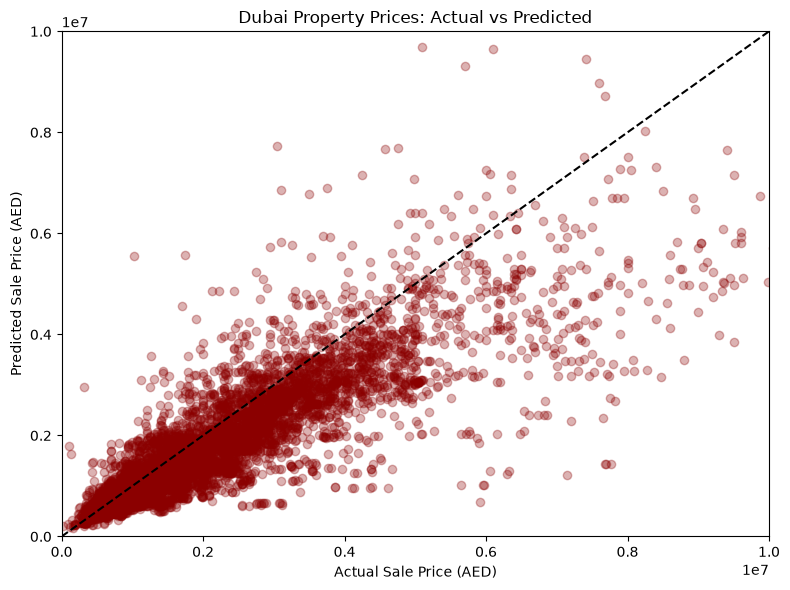

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plot_data = pd.DataFrame({
    "Actual": y_test,
    "Predicted": log_pred
}).sample(10000, random_state=42)

plt.figure(figsize=(8, 6))

plt.scatter(
    plot_data["Actual"],
    plot_data["Predicted"],
    alpha=0.3,
    color="darkred"
)

limit = 10_000_000

plt.plot(
    [0, limit],
    [0, limit],
    linestyle="--",
    color="black"
)

plt.xlim(0, limit)
plt.ylim(0, limit)

plt.xlabel("Actual Sale Price (AED)")
plt.ylabel("Predicted Sale Price (AED)")
plt.title("Dubai Property Prices: Actual vs Predicted")

plt.tight_layout()
plt.show()